# 3. Visualise South Australia (SA) battery energy storage system (BESS) Data

## Purpose
This notebook provides quick validation plots for the regenerated BESS aggregate.

## Run Flow
1. Setup
2. Aggregate Time-Series Check
3. Distribution Check

## Setup

Load the exported 5-minute and 30-minute aggregate files.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt


def find_publication_project(start: Path) -> Path:
    """Find publication/journal_article_1 from this moved notebook folder."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "scripts" / "sa_bess_publication_workflow.py").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find publication/journal_article_1 from the current working directory.")


PROJECT_DIR = find_publication_project(Path.cwd())
sys.path.insert(0, str(PROJECT_DIR / "scripts"))
from sa_bess_publication_workflow import PROCESSED_DIR

agg_5_path = PROCESSED_DIR / "sa_bess_aggregate_5min.csv"
agg_30_path = PROCESSED_DIR / "sa_bess_aggregate_30min_mean_power.csv"
missing_paths = [path for path in [agg_5_path, agg_30_path] if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing processed SA BESS aggregate files. Run 2_process_sa_bess_data.ipynb first. "
        f"Missing: {missing_paths}"
    )

agg_5 = pd.read_csv(agg_5_path, parse_dates=["datetime"])
agg_30 = pd.read_csv(agg_30_path, parse_dates=["datetime"])
print(f"Publication project: {PROJECT_DIR}")
agg_5.head()

Publication project: <local path redacted>


,datetime,underlying_load_kW,net_load_with_pv_kW,net_load_with_pv_and_battery_kW
0,2024-02-26 00:00:00,59.626250,60.197777,58.518860
1,2024-02-26 00:05:00,61.918807,62.491950,55.865564
2,2024-02-26 00:10:00,61.489673,62.067167,56.929443
3,2024-02-26 00:15:00,66.460214,67.022321,57.295780
4,2024-02-26 00:20:00,60.479927,61.052434,55.244534


## Aggregate Time-Series Check

Plot one representative week for the three target series.

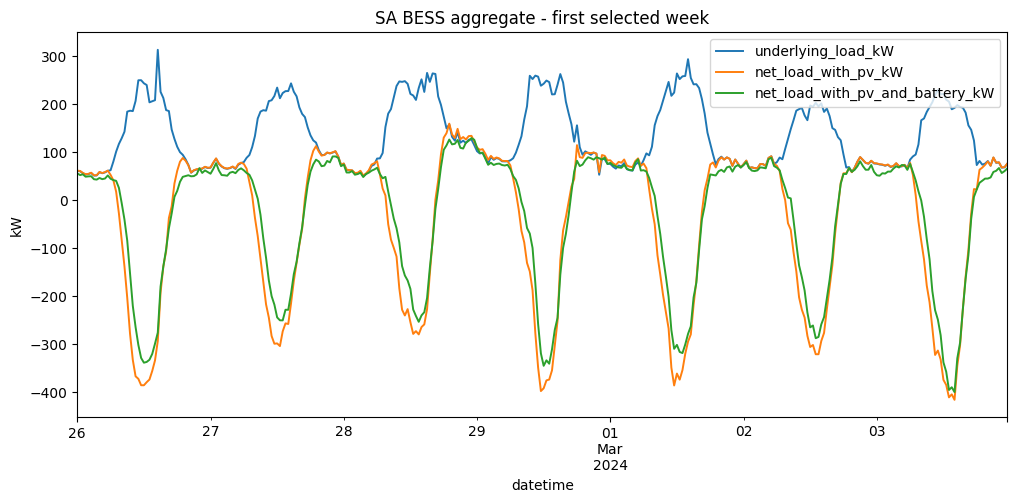

In [2]:
week = agg_30.iloc[: 48 * 7]
ax = week.set_index('datetime').plot(figsize=(12, 5), linewidth=1.4)
ax.set_ylabel('kW')
ax.set_title('SA BESS aggregate - first selected week')
plt.show()

## Distribution Check

Inspect summary statistics for the three 30-minute mean-power series.

In [3]:
agg_30.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,17520,2024-08-26 11:45:00,2024-02-26 00:00:00,2024-05-27 05:52:30,2024-08-26 11:45:00,2024-11-25 17:37:30,2025-02-24 23:30:00,NaN
underlying_load_kW,17520.0,140.612502,35.526393,86.65555,123.349129,188.741707,407.934603,63.85898
net_load_with_pv_kW,17520.0,-19.705574,-577.68912,-126.123607,67.69527,96.428857,256.586506,167.95743
net_load_with_pv_and_battery_kW,17520.0,-9.872144,-537.522817,-75.119724,56.561947,84.358774,255.927584,146.581874
